In [1]:
%pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [3]:
df = pd.read_csv("Listings (2).csv", encoding="latin1")
df.head()

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [4]:
df.dtypes

listing_id                       int64
name                            object
host_id                          int64
host_since                      object
host_location                   object
host_response_time              object
host_response_rate             float64
host_acceptance_rate           float64
host_is_superhost               object
host_total_listings_count      float64
host_has_profile_pic            object
host_identity_verified          object
neighbourhood                   object
district                        object
city                            object
latitude                       float64
longitude                      float64
property_type                   object
room_type                       object
accommodates                     int64
bedrooms                       float64
amenities                       object
price                            int64
minimum_nights                   int64
maximum_nights                   int64
review_scores_rating     

for i in df.columns:
    print(i)
    print("***********")
    print(df[i].value_counts())
    print("**********************")
    print()
    print(df[i].unique)
    print("**********************")
    print()

In [5]:
df['is_new_host'] = (df['host_total_listings_count'] <= 1).astype(int)
target = "is_new_host" 

In [6]:
num=df.select_dtypes(include=np.number).columns.to_list()
cat=df.select_dtypes(include='object').columns.to_list()

In [7]:
df['is_new_host'].value_counts(normalize=True)

is_new_host
1    0.539212
0    0.460788
Name: proportion, dtype: float64

In [8]:
cat

['name',
 'host_since',
 'host_location',
 'host_response_time',
 'host_is_superhost',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'district',
 'city',
 'property_type',
 'room_type',
 'amenities',
 'instant_bookable']

In [9]:
df['host_response_rate_missing'] = df['host_response_rate'].isna().astype(int)
df['host_response_rate'] = df['host_response_rate'].fillna(-1)

In [10]:
df['host_response_time'] = df['host_response_time'].fillna('unknown')
pd.get_dummies(df['host_response_time'], drop_first=True)

,unknown,within a day,within a few hours,within an hour
0,True,False,False,False
1,True,False,False,False
2,True,False,False,False
3,True,False,False,False
4,True,False,False,False
...,...,...,...,...
279707,True,False,False,False
279708,True,False,False,False
279709,True,False,False,False
279710,True,False,False,False


In [11]:
ordinal_order = {
    "unknown": 0,  # NaNs → 1
    "within an hour": 4,
    "within a few hours": 3,
    "within a day": 2,
    "a few days or more": 1
}
df['host_response_time_encoded'] = df['host_response_time'].map(ordinal_order)

In [12]:
df=df.drop('host_response_time',axis=1)

In [13]:
df['host_acceptance_rate_missing'] = df['host_acceptance_rate'].isna().astype(int)
df['host_acceptance_rate'] = df['host_acceptance_rate'].fillna(-1)

In [14]:
main_types = [
    'Entire apartment',
    'Private room in apartment',
    'Private room in house',
    'Entire house',
    'Entire condominium',
    'Room in boutique hotel',
    'Entire loft',
    'Private room in condominium']
df['property_group'] = df['property_type'].apply(
    lambda x: x if x in main_types else 'Others')

In [15]:
#doing frequency encoding
freq_map = df['property_group'].value_counts(normalize=True)

# Map the frequencies to a new column
df['property_group_freq'] = df['property_group'].map(freq_map)

In [16]:
df['city_freq'] = df['city'].map(df['city'].value_counts(normalize=True))

In [17]:
room_freq = df['room_type'].value_counts(normalize=True)

# Step 2: map back into the dataframe
df['room_type_freq'] = df['room_type'].map(room_freq)

In [18]:
df=df.drop('room_type',axis=1)

In [19]:
cols_to_drop = [
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
    "district",'listing_id','name','host_id','neighbourhood']
df = df.drop(columns=cols_to_drop)

In [20]:
df['review_scores_rating'] = df['review_scores_rating'].fillna(df['review_scores_rating'].median())

In [21]:
df['review_scores_rating'] .isna().sum()

np.int64(0)

In [22]:
def get_country(x):
    if isinstance(x, str):              # check valid string
        parts = x.split(",")            # split by comma
        return parts[-1].strip()        # take last part & remove spaces
    return np.nan                       # keep NaN for missing values

# Apply to the column
df['host_location'] = df['host_location'].apply(get_country)

In [23]:
df['host_location'].isna().sum()

np.int64(840)

In [24]:
mapping = {
    'FR': 'France',
    'US': 'United States',
    'IT': 'Italy',
    'AU': 'Australia',
    'BR': 'Brazil',
    'TH': 'Thailand',
    'ZA': 'South Africa',
    'MX': 'Mexico',
    'HK': 'Hong Kong',
    'CN': 'China',
    'JP': 'Japan',
    'IN': 'India',
    'DE': 'Germany',
    'ES': 'Spain',
    'CA': 'Canada',
    'IE': 'Ireland',
    'NL': 'Netherlands',
    'MY': 'Malaysia',
    'TW': 'Taiwan',
    'PH': 'Philippines',
    'KR': 'South Korea',
    'CH': 'Switzerland',
    'PT': 'Portugal',
    'AR': 'Argentina',
    'BE': 'Belgium',
    'IL': 'Israel',
    'UA': 'Ukraine',
    'AE': 'UAE',
    'MA': 'Morocco',
    'SA': 'Saudi Arabia',
    'SG': 'Singapore',
    'TR':'Turkey',

    # --- Special & Messy Values ---
    'USA': 'United States',
    'D.F.': 'Mexico',
    'Mexico DF': 'Mexico',
    'istanbul/turkey': 'Turkey',
    'Istanbul / Turkey': 'Turkey',
    'istanbul tÃ¼rkiye': 'Turkey',
    'TÃ¼rkiye': 'Turkey',
    'Bangkok/Thailand': 'Thailand',
    'Bangkok Thailand': 'Thailand',
    'Bangkok /LONDON': 'Thailand',
    'London': 'United Kingdom',
    'The Netherlands': 'Netherlands',

    # Chinese characters mapped to Hong Kong
    'Ã©Â¦â¢Ã¦Â¸Â¯': 'Hong Kong',
    'HongKong': 'Hong Kong',
    'Hong Kong/Ã¤Â¹ÂÃ©Â¾â¢Ã¤Â½ÂÃ¦â¢Â¦Ã¥Â¼Â¥Ã¦â¢Â¦Ã©Ââ240-252Ã¥ÂÂ·Ã§Â«â¹Ã¤Â¿Â¡Ã¥Â¤Â§Ã¥Å½Â¦9Ã¥Â­âÃ¦Â¥Â¼AÃ¥Â®Â¤': 'Hong Kong',

    # City → Country mapping
    'Istanbul': 'Turkey',
    'New York': 'United States',
    'Bangkok': 'Thailand'
    # ➜ You can add more if needed
}

In [25]:
 df['host_location']=df['host_location'].replace(mapping)
 rem_val=['France','United States','Australia','Italy','Brazil','Mexico','South Africa',
         'Turkey','Thailand','Hong Kong','China','United Kingdom','Germany','Spain','Canada',
         'India']
 df = df[df['host_location'].isin(rem_val)]

In [26]:
 df['host_location'].value_counts()

host_location
France            61568
United States     37776
Australia         31317
Italy             26762
Brazil            25296
Turkey            23057
Mexico            19115
South Africa      18001
Thailand          16207
Hong Kong          6060
China              2336
United Kingdom     2213
Germany             679
Spain               673
Canada              461
India               388
Name: count, dtype: int64

In [27]:
df=df.drop(['property_group','property_type'],axis=1)

In [28]:
df_superhost = pd.get_dummies(df['host_is_superhost'], prefix='host_is_superhost')

# Add to original dataframe
df = pd.concat([df, df_superhost], axis=1)

In [29]:
df=df.drop('host_is_superhost',axis=1)

In [30]:
df.shape

(271909, 27)

In [31]:
df['host_has_profile_pic'] = df['host_has_profile_pic'].astype(str).str.lower().map({'t': 1, 'f': 0, 'true': 1, 'false': 0})

In [32]:
df['city_freq'] = df['city'].map(df['city'].value_counts(normalize=True))

In [33]:
df=df.drop('city',axis=1)

In [34]:
#df['host_has_profile_pic'] = df_cat['host_has_profile_pic']
# 1. Create dummy columns
dummies = pd.get_dummies(df['host_has_profile_pic'], prefix='host_has_profile_pic')

# 2. Drop the original column
df = df.drop(columns=['host_has_profile_pic'])

# 3. Add the new dummy columns
df = pd.concat([df, dummies], axis=1)

In [35]:
import ast
df['amenities'] = df['amenities'].apply(lambda x: len(ast.literal_eval(x)))

In [36]:
df['host_since'] = pd.to_datetime(df['host_since'])

In [37]:
today = pd.Timestamp.today()
df['host_since_days'] = (today - df['host_since']).dt.days

In [38]:
df=df.drop('host_since',axis=1)

In [39]:
df.shape

(271909, 27)

In [40]:
loc_freq = df['host_location'].value_counts(normalize=True)

# Step 2: map back to df
df['host_location_freq'] = df['host_location'].map(loc_freq)

df[['host_location', 'host_location_freq']].head()

,host_location,host_location_freq
0,France,0.226429
1,France,0.226429
2,France,0.226429
3,France,0.226429
4,France,0.226429


In [41]:
df=df.drop('host_location',axis=1)

In [42]:
df['host_identity_verified'] = df['host_identity_verified'].astype(str).str.lower().map({'t': 1, 'f': 0, 'true': 1, 'false': 0})

In [43]:
df['is_new_host'] = df['is_new_host'].astype(str).str.lower().map({
    'true': 1, 't': 1, 'yes': 1, 'y': 1, '1': 1,
    'false': 0, 'f': 0, 'no': 0, 'n': 0, '0': 0
})

In [44]:
df.shape

(271909, 27)

In [45]:
df['bedrooms_missing'] = df['bedrooms'].isna().astype(int)

# Median imputation
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].median())

In [46]:
df = pd.get_dummies(df, columns=['instant_bookable' ], drop_first=True)

In [47]:
df.shape

(271909, 28)

In [48]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

In [49]:
df = df.drop(columns=[
    'host_has_profile_pic_0',
    'host_is_superhost_f'],axis=1)

In [50]:
df=df.drop('host_total_listings_count',axis=1)

In [51]:
df.shape

(271909, 25)

In [52]:
df.head()

,host_response_rate,host_acceptance_rate,host_identity_verified,latitude,longitude,accommodates,bedrooms,amenities,price,minimum_nights,...,host_acceptance_rate_missing,property_group_freq,city_freq,room_type_freq,host_is_superhost_t,host_has_profile_pic_1,host_since_days,host_location_freq,bedrooms_missing,instant_bookable_t
0,-1.0,-1.0,0,48.88668,2.33343,2,1.0,5,53,2,...,1,0.4969,0.232243,0.650687,0,1,5253,0.226429,0,0
1,-1.0,-1.0,1,48.88617,2.34515,2,1.0,8,120,2,...,1,0.4969,0.232243,0.650687,0,1,4526,0.226429,0,0
2,-1.0,-1.0,0,48.88112,2.31712,2,1.0,6,89,2,...,1,0.4969,0.232243,0.650687,0,1,4282,0.226429,0,0
3,-1.0,-1.0,1,48.84571,2.30584,2,1.0,5,58,2,...,1,0.4969,0.232243,0.650687,0,1,4508,0.226429,0,0
4,-1.0,-1.0,0,48.85500,2.26979,2,1.0,12,60,2,...,1,0.4969,0.232243,0.650687,0,1,4146,0.226429,0,0


In [53]:
df.shape

(271909, 25)

In [54]:
num=df.select_dtypes(include=np.number).columns.to_list()
cat=df.select_dtypes(include='object').columns.to_list()

In [55]:
num

['host_response_rate',
 'host_acceptance_rate',
 'host_identity_verified',
 'latitude',
 'longitude',
 'accommodates',
 'bedrooms',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'review_scores_rating',
 'is_new_host',
 'host_response_rate_missing',
 'host_response_time_encoded',
 'host_acceptance_rate_missing',
 'property_group_freq',
 'city_freq',
 'room_type_freq',
 'host_is_superhost_t',
 'host_has_profile_pic_1',
 'host_since_days',
 'host_location_freq',
 'bedrooms_missing',
 'instant_bookable_t']

In [56]:
len(num)

25

In [57]:
y = df['is_new_host']          # target
X = df.drop(columns=['is_new_host'])   # all features

In [58]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 271909 entries, 0 to 279711
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   host_response_rate            271909 non-null  float64
 1   host_acceptance_rate          271909 non-null  float64
 2   host_identity_verified        271909 non-null  int64  
 3   latitude                      271909 non-null  float64
 4   longitude                     271909 non-null  float64
 5   accommodates                  271909 non-null  int64  
 6   bedrooms                      271909 non-null  float64
 7   amenities                     271909 non-null  int64  
 8   price                         271909 non-null  int64  
 9   minimum_nights                271909 non-null  int64  
 10  maximum_nights                271909 non-null  int64  
 11  review_scores_rating          271909 non-null  float64
 12  host_response_rate_missing    271909 non-null  in

In [59]:
y.shape

(271909,)

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [61]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(217527, 24)
(54382, 24)
(217527,)
(54382,)


In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [63]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [64]:
model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [65]:
probabilities = model.predict_proba(X_test)
print(probabilities[:5])

[[0.18098158 0.81901842]
 [0.08185177 0.91814823]
 [0.58951052 0.41048948]
 [0.54050456 0.45949544]
 [0.62771942 0.37228058]]


In [66]:
y_pred = model.predict(X_test)

In [67]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\n TEst Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7327608399838181

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.71      0.71     25029
           1       0.75      0.75      0.75     29353

    accuracy                           0.73     54382
   macro avg       0.73      0.73      0.73     54382
weighted avg       0.73      0.73      0.73     54382


 TEst Confusion Matrix:
 [[17817  7212]
 [ 7321 22032]]


In [68]:
y_train_pred = model.predict(X_train)

In [69]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("\nTraining Classification Report:\n", classification_report(y_train, y_train_pred))
print("\nTraining Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))


Training Accuracy: 0.7334859580649759

Training Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.71      0.71    100114
           1       0.75      0.75      0.75    117413

    accuracy                           0.73    217527
   macro avg       0.73      0.73      0.73    217527
weighted avg       0.73      0.73      0.73    217527


Training Confusion Matrix:
 [[71107 29007]
 [28967 88446]]


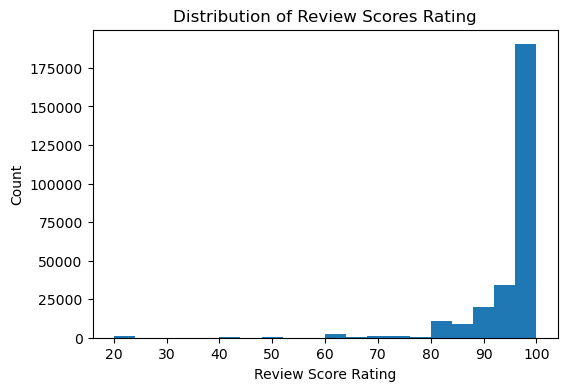

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df['review_scores_rating'].dropna(), bins=20)
plt.title('Distribution of Review Scores Rating')
plt.xlabel('Review Score Rating')
plt.ylabel('Count')
plt.show()

In [71]:
from sklearn.metrics import ConfusionMatrixDisplay

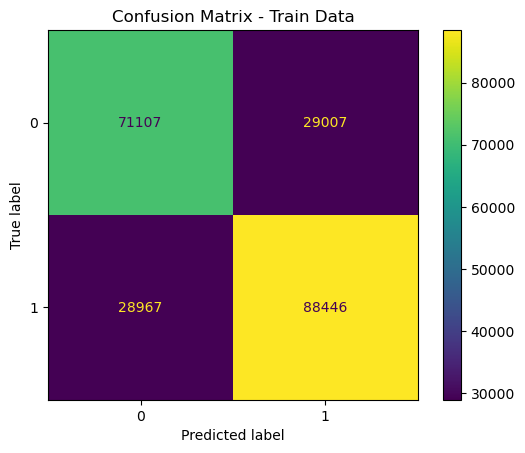

In [72]:
cm_train = confusion_matrix(y_train, y_train_pred)

disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
disp_train.plot()
plt.title("Confusion Matrix - Train Data")
plt.show()


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 271909 entries, 0 to 279711
Data columns (total 25 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   host_response_rate            271909 non-null  float64
 1   host_acceptance_rate          271909 non-null  float64
 2   host_identity_verified        271909 non-null  int64  
 3   latitude                      271909 non-null  float64
 4   longitude                     271909 non-null  float64
 5   accommodates                  271909 non-null  int64  
 6   bedrooms                      271909 non-null  float64
 7   amenities                     271909 non-null  int64  
 8   price                         271909 non-null  int64  
 9   minimum_nights                271909 non-null  int64  
 10  maximum_nights                271909 non-null  int64  
 11  review_scores_rating          271909 non-null  float64
 12  is_new_host                   271909 non-null  in

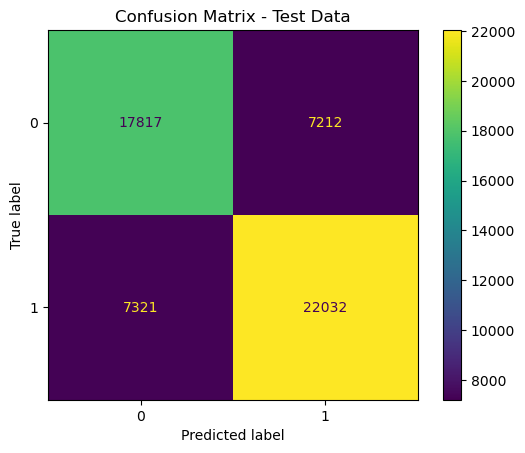

In [74]:
cm_test = confusion_matrix(y_test, y_pred)

disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp_train.plot()
plt.title("Confusion Matrix - Test Data")
plt.show()

In [75]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
DecisionTreeClassifier(
    criterion='gini',      # or 'entropy', 'log_loss'
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    random_state=42
)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [76]:
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [77]:
y_train_pred = dt.predict(X_train)
y_test_pred  = dt.predict(X_test)

In [78]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))


Train Accuracy: 1.0
Test Accuracy: 0.74798646611011
[[18636  6393]
 [ 7312 22041]]
              precision    recall  f1-score   support

           0       0.72      0.74      0.73     25029
           1       0.78      0.75      0.76     29353

    accuracy                           0.75     54382
   macro avg       0.75      0.75      0.75     54382
weighted avg       0.75      0.75      0.75     54382



In [79]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score

In [80]:
#finding the best parameters

In [81]:
dt = DecisionTreeClassifier(
    max_depth=7,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)


In [82]:
dt.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,7
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [83]:
y_pred = dt.predict(X_test)


In [84]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)



0.7558383288588135

In [85]:
#decision tree tuned

In [86]:
print("Train accuracy:", dt.score(X_train, y_train))
print("Test accuracy :", dt.score(X_test, y_test))
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

Train accuracy: 0.754504038579119
Test accuracy : 0.7558383288588135
[[18636  6393]
 [ 7312 22041]]
              precision    recall  f1-score   support

           0       0.72      0.74      0.73     25029
           1       0.78      0.75      0.76     29353

    accuracy                           0.75     54382
   macro avg       0.75      0.75      0.75     54382
weighted avg       0.75      0.75      0.75     54382



In [87]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("\nTraining Classification Report:\n", classification_report(y_train, y_train_pred))
print("\nTraining Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))

Training Accuracy: 1.0

Training Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    100114
           1       1.00      1.00      1.00    117413

    accuracy                           1.00    217527
   macro avg       1.00      1.00      1.00    217527
weighted avg       1.00      1.00      1.00    217527


Training Confusion Matrix:
 [[100114      0]
 [     0 117413]]


In [88]:
param_grid = {
    'max_depth': [3, 5, 7],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [5, 10]
}

In [89]:
from sklearn.model_selection import RandomizedSearchCV

random = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=20,   # only 20 combinations
    cv=5,
    n_jobs=-1,
    random_state=42
)

random.fit(X_train, y_train)


,estimator,DecisionTreeC...ndom_state=42)
,param_distributions,"{'max_depth': [3, 5, ...], 'min_samples_leaf': [5, 10], 'min_samples_split': [10, 20]}"
,n_iter,20
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [90]:
dt_tuned=DecisionTreeClassifier(criterion='gini',max_depth=7,min_samples_split=10)
scores=cross_val_score(estimator=dt_tuned,X=X_train,
                       y=y_train,
                       cv=10,
                       scoring='roc_auc')
scores.mean()

np.float64(0.8229259710013647)

In [91]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_train_pred = dt.predict(X_train)
print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("\nTraining Classification Report:\n", classification_report(y_train, y_train_pred))
print("\nTraining Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))

Training Accuracy: 0.754504038579119

Training Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.71      0.73    100114
           1       0.76      0.79      0.78    117413

    accuracy                           0.75    217527
   macro avg       0.75      0.75      0.75    217527
weighted avg       0.75      0.75      0.75    217527


Training Confusion Matrix:
 [[70807 29307]
 [24095 93318]]


In [92]:
y_test_pred = dt.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\n Test Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7558383288588135

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.72      0.73     25029
           1       0.76      0.79      0.78     29353

    accuracy                           0.76     54382
   macro avg       0.75      0.75      0.75     54382
weighted avg       0.76      0.76      0.76     54382


 Test Confusion Matrix:
 [[17898  7131]
 [ 6147 23206]]


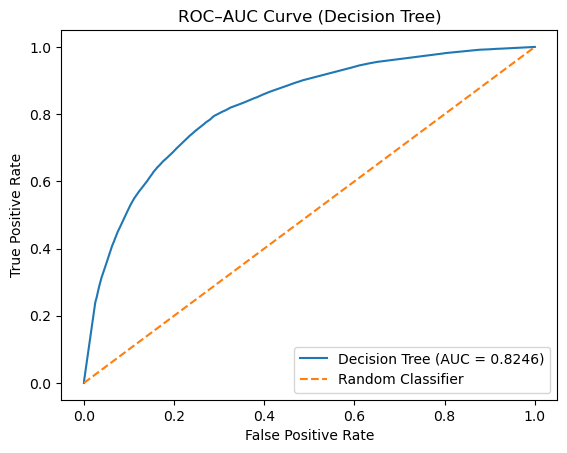

In [93]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities for the positive class (1)
y_test_proba = dt.predict_proba(X_test)[:, 1]

# ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

# AUC score
auc_score = roc_auc_score(y_test, y_test_proba)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'Decision Tree (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC–AUC Curve (Decision Tree)')
plt.legend()
plt.show()


In [94]:
#randomforest

In [95]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.model_selection import GridSearchCV

In [96]:
# instantiate the 'RandomForestClassifier'
# pass the required number of trees in the random forest to the parameter, 'n_estimators'
# pass the 'random_state' to obtain the same samples for each time you run the code
rf_classification = RandomForestClassifier(n_estimators = 10, random_state = 10)

# use fit() to fit the model on the train set
rf_model = rf_classification.fit(X_train, y_train)

In [97]:
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

In [98]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Train accuracy:", accuracy_score(y_train, y_train_pred))

print("\nClassification Report:Train\n")
print(classification_report(y_train, y_train_pred))


print("\nConfusion Matrix:Train\n")
print(confusion_matrix(y_train, y_train_pred))

print("Test accuracy:", accuracy_score(y_test, y_test_pred))

print("\nClassification Report:Test\n")

print(classification_report(y_test, y_test_pred))



print("\nConfusion Matrix:Test\n")
print(confusion_matrix(y_test, y_test_pred))


Train accuracy: 0.9911781066258442

Classification Report:Train

              precision    recall  f1-score   support

           0       0.99      0.99      0.99    100114
           1       0.99      0.99      0.99    117413

    accuracy                           0.99    217527
   macro avg       0.99      0.99      0.99    217527
weighted avg       0.99      0.99      0.99    217527


Confusion Matrix:Train

[[ 99511    603]
 [  1316 116097]]
Test accuracy: 0.7973961972711558

Classification Report:Test

              precision    recall  f1-score   support

           0       0.77      0.80      0.78     25029
           1       0.83      0.79      0.81     29353

    accuracy                           0.80     54382
   macro avg       0.80      0.80      0.80     54382
weighted avg       0.80      0.80      0.80     54382


Confusion Matrix:Test

[[20109  4920]
 [ 6098 23255]]


In [99]:
#OVERFITTING

In [100]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=10,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)


,n_estimators,200
,criterion,'gini'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [101]:
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

In [102]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Train accuracy:", accuracy_score(y_train, y_train_pred))

print("\nClassification Report:Train\n")
print(classification_report(y_train, y_train_pred))


print("\nConfusion Matrix:Train\n")
print(confusion_matrix(y_train, y_train_pred))

print("\n")

print("Test accuracy:", accuracy_score(y_test, y_test_pred))

print("\nClassification Report:Test\n")

print(classification_report(y_test, y_test_pred))



print("\nConfusion Matrix:Test\n")
print(confusion_matrix(y_test, y_test_pred))


Train accuracy: 0.8250607970504811

Classification Report:Train

              precision    recall  f1-score   support

           0       0.83      0.78      0.81    100114
           1       0.82      0.86      0.84    117413

    accuracy                           0.83    217527
   macro avg       0.83      0.82      0.82    217527
weighted avg       0.83      0.83      0.82    217527


Confusion Matrix:Train

[[ 78575  21539]
 [ 16515 100898]]


Test accuracy: 0.7949505351035269

Classification Report:Test

              precision    recall  f1-score   support

           0       0.79      0.76      0.77     25029
           1       0.80      0.83      0.81     29353

    accuracy                           0.79     54382
   macro avg       0.79      0.79      0.79     54382
weighted avg       0.79      0.79      0.79     54382


Confusion Matrix:Test

[[18902  6127]
 [ 5024 24329]]


In [103]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_depth': [10, 15, None],
    'min_samples_leaf': [5, 10],
    'max_features': ['sqrt']
}

rf = RandomForestClassifier(
    n_estimators=150,
    n_jobs=-1,
    random_state=42
)

rf_random = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=5,      # 🔥 ONLY 5
    cv=2,          # 🔥 ONLY 2
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

rf_random.fit(X_train, y_train)


Fitting 2 folds for each of 5 candidates, totalling 10 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [10, 15, ...], 'max_features': ['sqrt'], 'min_samples_leaf': [5, 10]}"
,n_iter,5
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,2
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [104]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Train accuracy:", accuracy_score(y_train, y_train_pred))

print("\nClassification Report:Train\n")
print(classification_report(y_train, y_train_pred))


print("\nConfusion Matrix:Train\n")
print(confusion_matrix(y_train, y_train_pred))

print("\n")

print("Test accuracy:", accuracy_score(y_test, y_test_pred))

print("\nClassification Report:Test\n")

print(classification_report(y_test, y_test_pred))



print("\nConfusion Matrix:Test\n")
print(confusion_matrix(y_test, y_test_pred))


Train accuracy: 0.8250607970504811

Classification Report:Train

              precision    recall  f1-score   support

           0       0.83      0.78      0.81    100114
           1       0.82      0.86      0.84    117413

    accuracy                           0.83    217527
   macro avg       0.83      0.82      0.82    217527
weighted avg       0.83      0.83      0.82    217527


Confusion Matrix:Train

[[ 78575  21539]
 [ 16515 100898]]


Test accuracy: 0.7949505351035269

Classification Report:Test

              precision    recall  f1-score   support

           0       0.79      0.76      0.77     25029
           1       0.80      0.83      0.81     29353

    accuracy                           0.79     54382
   macro avg       0.79      0.79      0.79     54382
weighted avg       0.79      0.79      0.79     54382


Confusion Matrix:Test

[[18902  6127]
 [ 5024 24329]]


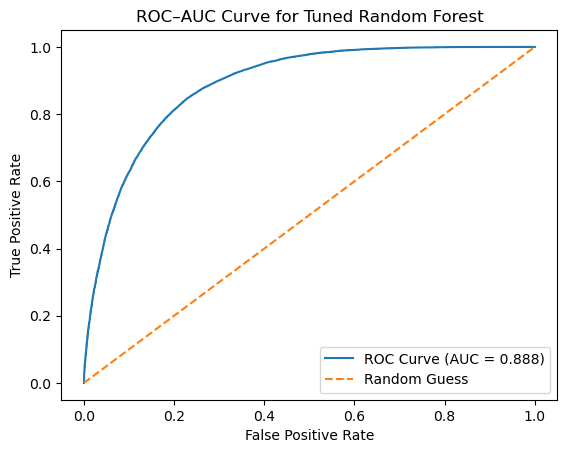

In [105]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities for the positive class (class = 1)
y_test_proba = rf_random.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

# Compute AUC score
roc_auc = roc_auc_score(y_test, y_test_proba)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC–AUC Curve for Tuned Random Forest')
plt.legend()
plt.show()


In [106]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

In [107]:
# instantiate the 'AdaBoostClassifier'
# n_estimators: number of estimators at which boosting is terminated
# pass the 'random_state' to obtain the same results for each code implementation
ada_model = AdaBoostClassifier(n_estimators = 40, random_state = 10)

# fit the model using fit() on train data
ada_model.fit(X_train, y_train)

,estimator,None
,n_estimators,40
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,10


In [108]:
# Fit the model
ada_model.fit(X_train, y_train)

# Predict on train data
y_train_pred = ada_model.predict(X_train)

# Predict on test data
y_test_pred = ada_model.predict(X_test)

In [109]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Train accuracy:", accuracy_score(y_train, y_train_pred))

print("\nClassification Report:Train\n")
print(classification_report(y_train, y_train_pred))


print("\nConfusion Matrix:Train\n")
print(confusion_matrix(y_train, y_train_pred))

print("\n")

print("Test accuracy:", accuracy_score(y_test, y_test_pred))

print("\nClassification Report:Test\n")

print(classification_report(y_test, y_test_pred))



print("\nConfusion Matrix:Test\n")
print(confusion_matrix(y_test, y_test_pred))


Train accuracy: 0.7508493198545468

Classification Report:Train

              precision    recall  f1-score   support

           0       0.73      0.72      0.73    100114
           1       0.77      0.78      0.77    117413

    accuracy                           0.75    217527
   macro avg       0.75      0.75      0.75    217527
weighted avg       0.75      0.75      0.75    217527


Confusion Matrix:Train

[[72132 27982]
 [26215 91198]]


Test accuracy: 0.7501746901548306

Classification Report:Test

              precision    recall  f1-score   support

           0       0.73      0.72      0.73     25029
           1       0.77      0.77      0.77     29353

    accuracy                           0.75     54382
   macro avg       0.75      0.75      0.75     54382
weighted avg       0.75      0.75      0.75     54382


Confusion Matrix:Test

[[18132  6897]
 [ 6689 22664]]


In [110]:
#tuning_parameters = {'learning_rate': [0.01, 0.05, 0.1, 0.5, 1, 10],
                     #'n_estimators': [30, 40, 50, 60, 70]}


In [111]:
#mild tweaking unable to tune ada boost heavy time constrained

In [112]:
from sklearn.ensemble import AdaBoostClassifier

# Tiny tweak: increase n_estimators a bit and adjust learning rate
adaboost = AdaBoostClassifier(
    n_estimators=100,   # default is 50 → small bump
    learning_rate=0.8,  # default is 1 → slightly slower learning, can help generalization
    random_state=42
)

adaboost.fit(X_train, y_train)

y_train_pred = adaboost.predict(X_train)
y_test_pred = adaboost.predict(X_test)




In [113]:

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

Training Accuracy: 0.7560394801564864
Test Accuracy: 0.7556728329226582


In [114]:
print("Classification Report (Train Data):")
print(classification_report(y_train, y_train_pred))

print("Classification Report (Test Data):")
print(classification_report(y_test, y_test_pred))


Classification Report (Train Data):
              precision    recall  f1-score   support

           0       0.74      0.73      0.73    100114
           1       0.77      0.78      0.78    117413

    accuracy                           0.76    217527
   macro avg       0.75      0.75      0.75    217527
weighted avg       0.76      0.76      0.76    217527

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.74      0.73      0.73     25029
           1       0.77      0.78      0.77     29353

    accuracy                           0.76     54382
   macro avg       0.75      0.75      0.75     54382
weighted avg       0.76      0.76      0.76     54382



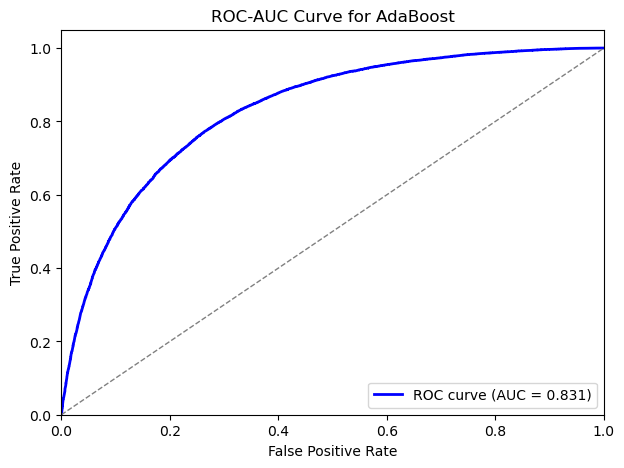

In [115]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class
y_probs = adaboost.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve for AdaBoost')
plt.legend(loc='lower right')
plt.show()


In [116]:
model5 = GradientBoostingClassifier(random_state=42)
model5.fit(X_train, y_train)




,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [117]:
y_train_pred = model5.predict(X_train)
y_test_pred = model5.predict(X_test)

In [118]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Train accuracy:", accuracy_score(y_train, y_train_pred))

print("\nClassification Report:Train\n")
print(classification_report(y_train, y_train_pred))


print("\nConfusion Matrix:Train\n")
print(confusion_matrix(y_train, y_train_pred))

print("\n")

print("Test accuracy:", accuracy_score(y_test, y_test_pred))

print("\nClassification Report:Test\n")

print(classification_report(y_test, y_test_pred))



print("\nConfusion Matrix:Test\n")
print(confusion_matrix(y_test, y_test_pred))


Train accuracy: 0.7715410041052375

Classification Report:Train

              precision    recall  f1-score   support

           0       0.76      0.73      0.75    100114
           1       0.78      0.80      0.79    117413

    accuracy                           0.77    217527
   macro avg       0.77      0.77      0.77    217527
weighted avg       0.77      0.77      0.77    217527


Confusion Matrix:Train

[[73479 26635]
 [23061 94352]]


Test accuracy: 0.7691699459379941

Classification Report:Test

              precision    recall  f1-score   support

           0       0.76      0.74      0.75     25029
           1       0.78      0.80      0.79     29353

    accuracy                           0.77     54382
   macro avg       0.77      0.77      0.77     54382
weighted avg       0.77      0.77      0.77     54382


Confusion Matrix:Test

[[18426  6603]
 [ 5950 23403]]


In [119]:
#tuning GB

In [120]:
gb = GradientBoostingClassifier( random_state=42)

In [121]:
params = {
    'n_estimators': [70, 90],
    'learning_rate': [0.05, 0.1]
}



In [122]:
grid_gb = GridSearchCV(estimator=gb, param_grid=params, cv = 3, n_jobs=-1)

In [123]:
grid_gb.fit(X_train,y_train)

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.05, 0.1], 'n_estimators': [70, 90]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [124]:
y_train_pred = grid_gb .predict(X_train)
y_test_pred = grid_gb .predict(X_test)

In [125]:
!pip install statsmodels

In [126]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Train accuracy:", accuracy_score(y_train, y_train_pred))

print("\nClassification Report:Train\n")
print(classification_report(y_train, y_train_pred))


print("\nConfusion Matrix:Train\n")
print(confusion_matrix(y_train, y_train_pred))

print("\n")

print("Test accuracy:", accuracy_score(y_test, y_test_pred))

print("\nClassification Report:Test\n")

print(classification_report(y_test, y_test_pred))



print("\nConfusion Matrix:Test\n")
print(confusion_matrix(y_test, y_test_pred))


Train accuracy: 0.7696837633948889

Classification Report:Train

              precision    recall  f1-score   support

           0       0.76      0.73      0.75    100114
           1       0.78      0.80      0.79    117413

    accuracy                           0.77    217527
   macro avg       0.77      0.77      0.77    217527
weighted avg       0.77      0.77      0.77    217527


Confusion Matrix:Train

[[73477 26637]
 [23463 93950]]


Test accuracy: 0.7670736640800265

Classification Report:Test

              precision    recall  f1-score   support

           0       0.75      0.74      0.74     25029
           1       0.78      0.79      0.79     29353

    accuracy                           0.77     54382
   macro avg       0.77      0.76      0.77     54382
weighted avg       0.77      0.77      0.77     54382


Confusion Matrix:Test

[[18409  6620]
 [ 6047 23306]]


In [127]:
!pip install xgboost

In [128]:
from xgboost import XGBClassifier

In [129]:
xgb_model = XGBClassifier(max_depth = 10, gamma = 1)

# fit the model using fit() on train data
xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [130]:
y_train_pred = xgb_model.predict(X_train)
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Train Classification Report:\n", classification_report(y_train, y_train_pred))

print("Train Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))
# Predict on test data
y_test_pred = xgb_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test Classification Report:\n", classification_report(y_test, y_test_pred))

# Optional: Confusion matrices

print("Test Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

Train Accuracy: 0.8639387294450804
Train Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.82      0.85    100114
           1       0.85      0.90      0.88    117413

    accuracy                           0.86    217527
   macro avg       0.87      0.86      0.86    217527
weighted avg       0.86      0.86      0.86    217527

Train Confusion Matrix:
 [[ 81857  18257]
 [ 11340 106073]]
Test Accuracy: 0.8052112831451583
Test Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.76      0.78     25029
           1       0.80      0.84      0.82     29353

    accuracy                           0.81     54382
   macro avg       0.81      0.80      0.80     54382
weighted avg       0.81      0.81      0.80     54382

Test Confusion Matrix:
 [[18988  6041]
 [ 4552 24801]]


In [131]:
def plot_roc(model):
    y_pred_prob = xgb_model.predict_proba(X_test)[:,1]
    
    # the roc_curve() returns the values for false positive rate, true positive rate and threshold
    # pass the actual target values and predicted probabilities to the function
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

    # plot the ROC curve
    plt.plot(fpr, tpr)

    # set limits for x and y axes
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])

    # plot the straight line showing worst prediction for the model
    plt.plot([0, 1], [0, 1],'r--')

    # add plot and axes labels
    # set text size using 'fontsize'
    plt.title('ROC curve for XG BOOST CLASSIFIER', fontsize = 15)
    plt.xlabel('False positive rate (1-Specificity)', fontsize = 15)
    plt.ylabel('True positive rate (Sensitivity)', fontsize = 15)

    # add the AUC score to the plot
    # 'x' and 'y' gives position of the text
    # 's' is the text 
    # use round() to round-off the AUC score upto 4 digits
    plt.text(x = 0.82, y = 0.3, s = ('AUC Score:',round(roc_auc_score(y_test, y_pred_prob),4)))

    # plot the grid
    plt.grid(True)

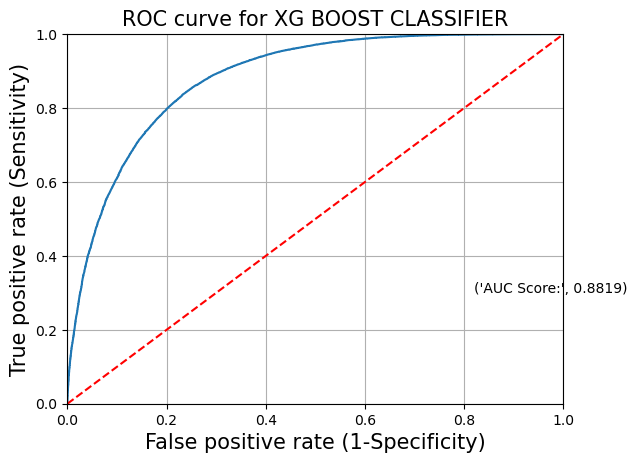

In [132]:
plot_roc(xgb_model)

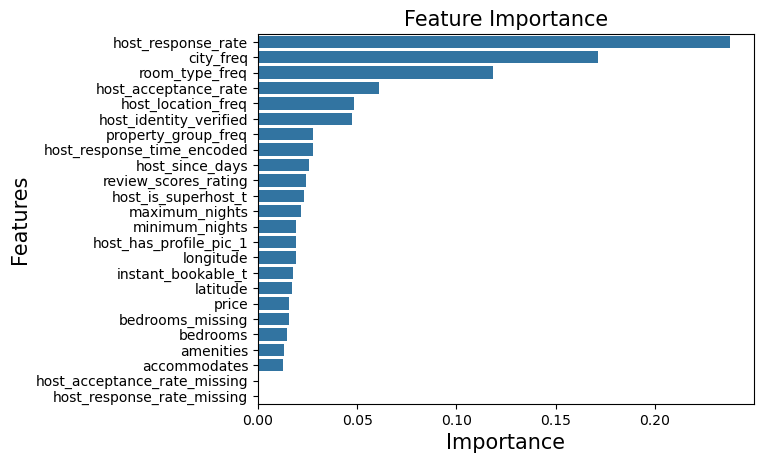

In [133]:
important_features = pd.DataFrame({
    'Features': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)
# create a barplot to visualize the features based on their importance
sns.barplot(x = 'Importance', y = 'Features', data = important_features)

# add plot and axes labels
# set text size using 'fontsize'
plt.title('Feature Importance', fontsize = 15)
plt.xlabel('Importance', fontsize = 15)
plt.ylabel('Features', fontsize = 15)

# display the plot
plt.show()

In [134]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# parameter space (small on purpose → fast)
param_dist = {
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'gamma': [0, 1, 2]
}

# base model
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

# randomized search
xgb_random = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=10,        # ONLY 10 tries
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

# fit
xgb_random.fit(X_train, y_train)

# best params
print("Best parameters:", xgb_random.best_params_)

# final model
best_xgb_model = xgb_random.best_estimator_


Best parameters: {'max_depth': 6, 'learning_rate': 0.2, 'gamma': 2}


In [135]:

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# parameter space (small on purpose → fast)
param_dist = {
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'gamma': [0, 1, 2]
}

# base model
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

# randomized search
xgb_random = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=10,        # ONLY 10 tries
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

# fit
xgb_random.fit(X_train, y_train)

# best params
print("Best parameters:", xgb_random.best_params_)

# final model
best_xgb_model = xgb_random.best_estimator_


Best parameters: {'max_depth': 6, 'learning_rate': 0.2, 'gamma': 2}


In [136]:
# predict on TRAIN
y_train_pred = best_xgb_model.predict(X_train)
y_train_proba = best_xgb_model.predict_proba(X_train)[:, 1]

# predict on TEST
y_test_pred = best_xgb_model.predict(X_test)
y_test_proba = best_xgb_model.predict_proba(X_test)[:, 1]


In [137]:
from sklearn.metrics import accuracy_score, roc_auc_score

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy :", accuracy_score(y_test, y_test_pred))

print("Train ROC AUC :", roc_auc_score(y_train, y_train_proba))
print("Test ROC AUC  :", roc_auc_score(y_test, y_test_proba))


Train Accuracy: 0.8053483015901475
Test Accuracy : 0.7939391710492443
Train ROC AUC : 0.8842070697764355
Test ROC AUC  : 0.8701647696004083


In [138]:
y_train_pred = best_xgb_model.predict(X_train)
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Train Classification Report:\n", classification_report(y_train, y_train_pred))

print("Train Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))
# Predict on test data
y_test_pred = best_xgb_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test Classification Report:\n", classification_report(y_test, y_test_pred))

# Optional: Confusion matrices

print("Test Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

Train Accuracy: 0.8053483015901475
Train Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.76      0.78    100114
           1       0.80      0.85      0.82    117413

    accuracy                           0.81    217527
   macro avg       0.81      0.80      0.80    217527
weighted avg       0.81      0.81      0.80    217527

Train Confusion Matrix:
 [[75689 24425]
 [17917 99496]]
Test Accuracy: 0.7939391710492443
Test Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.75      0.77     25029
           1       0.80      0.83      0.81     29353

    accuracy                           0.79     54382
   macro avg       0.79      0.79      0.79     54382
weighted avg       0.79      0.79      0.79     54382

Test Confusion Matrix:
 [[18738  6291]
 [ 4915 24438]]


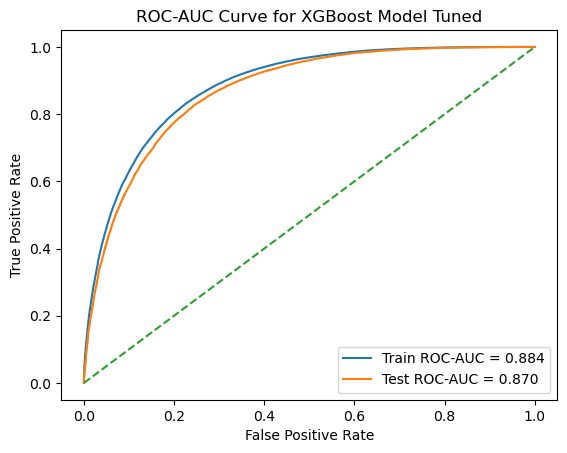

In [139]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities
y_train_prob = best_xgb_model.predict_proba(X_train)[:, 1]
y_test_prob = best_xgb_model.predict_proba(X_test)[:, 1]

# ROC values
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)

# AUC scores
train_auc = roc_auc_score(y_train, y_train_prob)
test_auc = roc_auc_score(y_test, y_test_prob)

# Plot ROC Curve
plt.figure()
plt.plot(fpr_train, tpr_train, label=f"Train ROC-AUC = {train_auc:.3f}")
plt.plot(fpr_test, tpr_test, label=f"Test ROC-AUC = {test_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve for XGBoost Model Tuned")
plt.legend()
plt.show()


In [140]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [141]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# initialize model (default k = 5)
knn = KNeighborsClassifier()

# fit the model
knn.fit(X_train, y_train)

# predictions
y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)

# accuracy
print("Train Accuracy:", knn.score(X_train, y_train))
print("Test Accuracy:", knn.score(X_test, y_test))

# classification report (test set)
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

# confusion matrix (test set)
print("\nConfusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_test_pred))


# classification report (test set)
print("\nClassification Report (Train Set):")
print(classification_report(y_train, y_train_pred))

# confusion matrix (test set)
print("\nConfusion Matrix (Train Set):")
print(confusion_matrix(y_train, y_train_pred))


Train Accuracy: 0.8265962386278485
Test Accuracy: 0.7539075429370012

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.73      0.73      0.73     25029
           1       0.77      0.78      0.77     29353

    accuracy                           0.75     54382
   macro avg       0.75      0.75      0.75     54382
weighted avg       0.75      0.75      0.75     54382


Confusion Matrix (Test Set):
[[18239  6790]
 [ 6593 22760]]

Classification Report (Train Set):
              precision    recall  f1-score   support

           0       0.82      0.80      0.81    100114
           1       0.83      0.85      0.84    117413

    accuracy                           0.83    217527
   macro avg       0.83      0.82      0.83    217527
weighted avg       0.83      0.83      0.83    217527


Confusion Matrix (Train Set):
[[80304 19810]
 [17910 99503]]


In [142]:
import pandas as pd
import numpy as np

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [143]:
Xnew=X
Xnew = add_constant(X)

In [144]:
vif_df = pd.DataFrame()
vif_df['feature'] = Xnew.columns
vif_df['VIF'] = [variance_inflation_factor(Xnew.values, i)
                 for i in range(Xnew.shape[1])]

vif_df

,feature,VIF
0,const,488.608879
1,host_response_rate,51.647450
2,host_acceptance_rate,21.042429
3,host_identity_verified,1.141489
4,latitude,1.684983
5,longitude,1.289144
6,accommodates,1.916834
7,bedrooms,1.722512
8,amenities,1.331601
9,price,1.043562


In [145]:
import pandas as pd
from statsmodels.tools.tools import add_constant

feature_names = X.columns  # original feature names

X_train_df = pd.DataFrame(X_train, columns=feature_names, index=y_train.index)
X_test_df  = pd.DataFrame(X_test,  columns=feature_names, index=y_test.index)

X_train_new = add_constant(X_train_df, has_constant='add')
X_test_new  = add_constant(X_test_df,  has_constant='add')

In [146]:
import statsmodels.api as sm

logit_model = sm.Logit(y_train, X_train_new)
result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.538184
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            is_new_host   No. Observations:               217527
Model:                          Logit   Df Residuals:                   217502
Method:                           MLE   Df Model:                           24
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.2200
Time:                        12:45:00   Log-Likelihood:            -1.1707e+05
converged:                       True   LL-Null:                   -1.5009e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                            0.2248      0.005     43.879      0.000